In [2]:
import pandas as pd
df = pd.read_csv('Drug.csv')

In [3]:
df

,Age,Sex,BP,Cholesterol,Na,K,Drug
0,23,F,HIGH,HIGH,0.792535,0.031258,drugY
1,47,M,LOW,HIGH,0.739309,0.056468,drugC
2,47,M,LOW,HIGH,0.697269,0.068944,drugC
3,28,F,NORMAL,HIGH,0.563682,0.072289,drugX
4,61,F,LOW,HIGH,0.559294,0.030998,drugY
...,...,...,...,...,...,...,...
195,56,F,LOW,HIGH,0.848774,0.073380,drugC
196,16,M,LOW,HIGH,0.743021,0.061886,drugC
197,52,M,NORMAL,HIGH,0.549945,0.055581,drugX
198,23,M,NORMAL,NORMAL,0.784520,0.055959,drugX


In [4]:
df['Na_to_K'] = df['Na'] / df['K']
df = df.drop(columns=['Na', 'K'])
display(df.head())

,Age,Sex,BP,Cholesterol,Drug,Na_to_K
0,23,F,HIGH,HIGH,drugY,25.354629
1,47,M,LOW,HIGH,drugC,13.092530
2,47,M,LOW,HIGH,drugC,10.113556
3,28,F,NORMAL,HIGH,drugX,7.797618
4,61,F,LOW,HIGH,drugY,18.042906


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Drug'] = le.fit_transform(df['Drug'])
df['BP'] = le.fit_transform(df['BP'])
df['Sex'] = le.fit_transform(df['Sex'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])

In [7]:
cols = list(df.columns)
cols.insert(4, cols.pop(cols.index('Na_to_K')))
cols.insert(5, cols.pop(cols.index('Drug')))
df = df[cols]
display(df.head())

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.354629,4
1,47,1,1,0,13.092530,2
2,47,1,1,0,10.113556,2
3,28,0,2,0,7.797618,3
4,61,0,1,0,18.042906,4


In [8]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [9]:
X

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.354629
1,47,1,1,0,13.092530
2,47,1,1,0,10.113556
3,28,0,2,0,7.797618
4,61,0,1,0,18.042906
...,...,...,...,...,...
195,56,0,1,0,11.566830
196,16,1,1,0,12.006286
197,52,1,2,0,9.894478
198,23,1,2,1,14.019550


In [10]:
y

,Drug
0,4
1,2
2,2
3,3
4,4
...,...
195,2
196,2
197,3
198,3


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [12]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

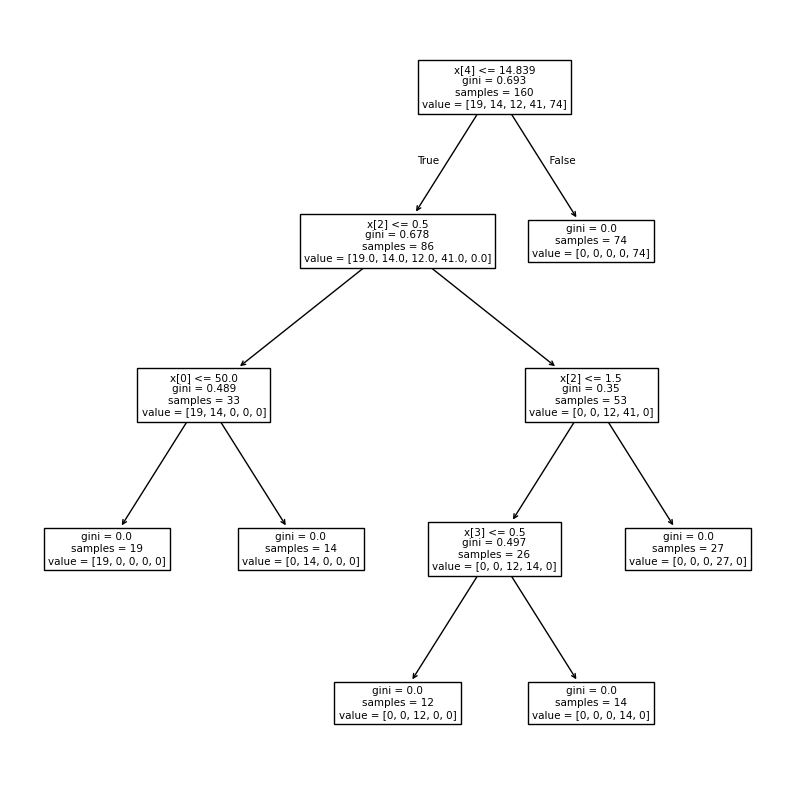

In [14]:
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(dt.fit(X_train,y_train))
plt.show()

In [15]:
clf_entropy = DecisionTreeClassifier(criterion='entropy',random_state=1,max_depth=4)
clf_entropy.fit(X_train,y_train)
Y_pred = clf_entropy.predict(X_test)

1.0


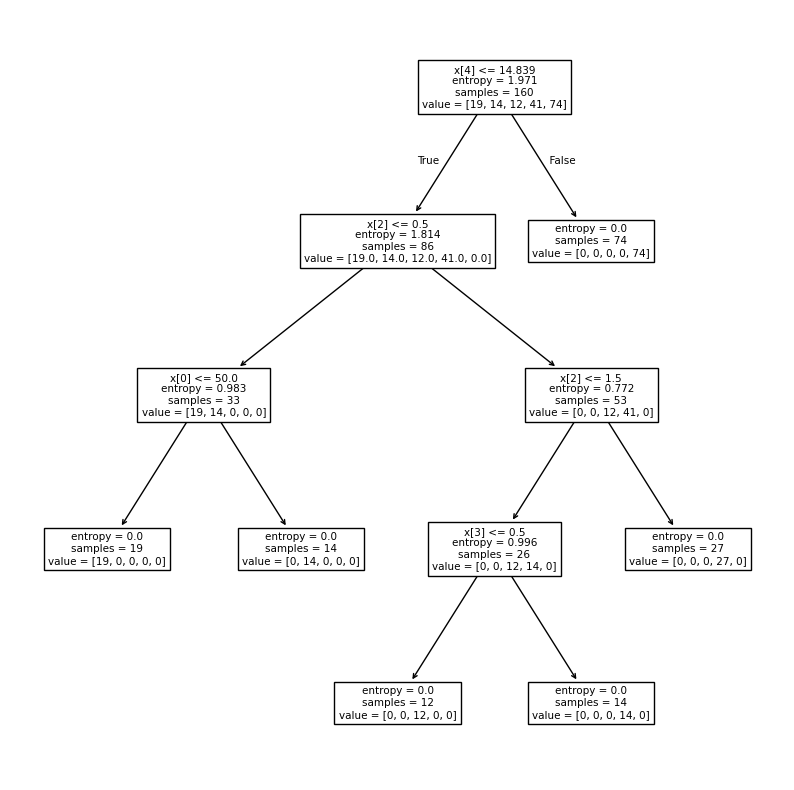

In [16]:
print(accuracy_score(y_test,Y_pred))
plt.figure(figsize=(10,10))
tree.plot_tree(clf_entropy.fit(X_train,y_train))
plt.show()